# Study 846 — Blockbuster Game-Launch Drift — for the quants 🔬

The full battery: one-sample *t* and a Newey-West (HAC) *t* per window, a random-window placebo, per-publisher and sub-era splits, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `ba0709a58928`. **ATVI** (delisted 2023-10-13) carries no tape, so its four launches sit in the excluded funnel.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from game_launch import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching TTWO + EA + NTDOY + UBSFY + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} launches resolved "
      f"(4 ATVI launches carry no tape — Activision delisted 2023-10-13)")


panel loaded; 33 of 37 launches resolved (4 ATVI launches carry no tape — Activision delisted 2023-10-13)


## 1. One-sample *t* (and HAC *t*) across independent launches

Each launch is one independent event pooled across the four publishers, so the unit is a one-sample *t* of the per-event abnormal return — **not** a daily panel (which would fake precision). A Newey-West *t* on the date-ordered series is a robustness cross-check; with well-spaced events it lands close by.

In [2]:
for label, col in [('1wk run-up','pre_s'),('2wk run-up','pre_l'),('1wk drift','post_s'),('20d drift','post_l')]:
    s = st.one_sample_t(inc[col].values)
    nw = st.newey_west_t(inc.sort_values('anchor_date')[col].values)
    print(f'{label:<11s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}  t_NW={nw:+.3f}')

1wk run-up  n=33  mean=-1.381%  sd=6.03%  t=-1.316  t_NW=-1.844
2wk run-up  n=33  mean=-1.581%  sd=7.22%  t=-1.259  t_NW=-1.626
1wk drift   n=33  mean=+0.339%  sd=5.09%  t=+0.383  t_NW=+0.382
20d drift   n=33  mean=-0.165%  sd=9.70%  t=-0.098  t_NW=-0.099


## 2. Per-publisher & sub-era splits — does anything hold up?

A real effect should show in *most* publishers and *both* halves of the sample. The 20-day drift does the opposite: **TTWO** +1.23% (*t* +0.54), **EA** +0.65% (*t* +0.40), **NTDOY** +2.77% (*t* +1.16) but **UBSFY** -5.60% (*t* -0.97) — the signs scatter and nothing clears |*t*| ≥ 2. And the eras flip: early +1.16% (*t* +0.70) vs late -1.42% (*t* -0.49) — the opposite of a stable, era-spanning effect.

In [3]:
print('by publisher (20-day drift):')
for pub in dt.PUBLISHERS:
    sub = inc[inc['publisher']==pub]; s = st.one_sample_t(sub['post_l'].values)
    print(f'  {pub:<6s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}')
srt = inc.sort_values('anchor_date'); h = len(srt)//2
print('by era (20-day drift):')
for lab, part in [('early', srt.iloc[:h]), ('late', srt.iloc[h:])]:
    s = st.one_sample_t(part['post_l'].values)
    print(f'  {lab:<5s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}')

by publisher (20-day drift):
  TTWO   n= 7  mean=+1.228%  t=+0.535
  EA     n= 9  mean=+0.648%  t=+0.401
  NTDOY  n= 9  mean=+2.766%  t=+1.164
  UBSFY  n= 8  mean=-5.597%  t=-0.971
by era (20-day drift):
  early n=16  mean=+1.164%  t=+0.697
  late  n=17  mean=-1.416%  t=-0.489


## 3. Random-window placebo — is the move inside the luck cloud?

For each event we redraw a random, non-launch window on the event's OWN publisher vs SPY and recompute the abnormal return; 20 seeds × 200 draws. If the observed mean sits in the tail of that null, it isn't ordinary tracking noise. Here both the run-up and the 20-day drift sit deep inside.

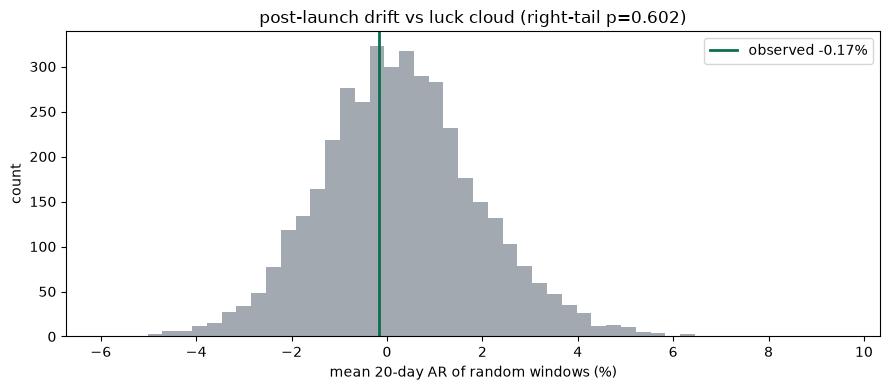

placebo: {'obs': -0.0017, 'placebo_mean': 0.0026, 'placebo_sd': 0.0165, 'p_value': 0.6018, 'n_draws': 4000}


In [4]:
pl = st.placebo_pvalue(ev, prices, 'post_l', k=20, tail='right')
spy = prices[dt.BENCHMARK]
pub_arr = {}
for p in dt.PUBLISHERS:
    common = prices[p].index.intersection(spy.index).sort_values()
    pub_arr[p] = (prices[p].reindex(common).to_numpy(float), spy.reindex(common).to_numpy(float), len(common))
rng = np.random.default_rng(999); draws = []
epubs = inc['publisher'].to_numpy()
for _ in range(4000):
    vals = []
    for p in epubs:
        pa, sa, m = pub_arr[p]; q = int(rng.integers(0, m-21))
        vals.append(float(pa[q+20]/pa[q] - sa[q+20]/sa[q]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#0b6e4f', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 20-day AR of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"post-launch drift vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 4. Jackknife — is the (already-zero) drift one launch, or broad?

In [5]:
x = inc['post_l'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = -0.098
jackknife t range [-0.324, +1.111] over 33 leave-one-out draws


## 5. Tradability — net of costs

Even gross there is no significant edge; costs only deepen the (insignificant) windows. 'Buy the hype' is a *losing* long here, and there is no momentum to ride after the ship. Execution lag = 0 (the date is calendar-known months ahead — the one thing that *is* real is that you could place the trade on time; there's just nothing to place it on).

In [6]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('pre_l','2wk run-up'),('post_l','20d drift')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<11s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

2wk run-up  gross -1.581% (t=-1.26)  net@5 -1.681% (t=-1.34)  net@10 -1.781% (t=-1.42)
20d drift   gross -0.165% (t=-0.10)  net@5 -0.265% (t=-0.16)  net@10 -0.365% (t=-0.22)


## 6. Synthetic positive control — the detector works; the tape has no bump

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted launch drift with unit slope. At n = 32 with a 20-day AR the null fires |*t*| ≥ 2 on only ~1/20 seeds — an honest false-positive rate — and a real planted drift is recovered (+1% planted → +1% measured). The machinery is fine; the real tape simply has nothing to find.

null: mean t=-0.24 sd=1.21  |t|>=2 in 1/20 seeds


planted +2%: mean AR +1.696%  t=+1.38
planted +4%: mean AR +3.696%  t=+3.02


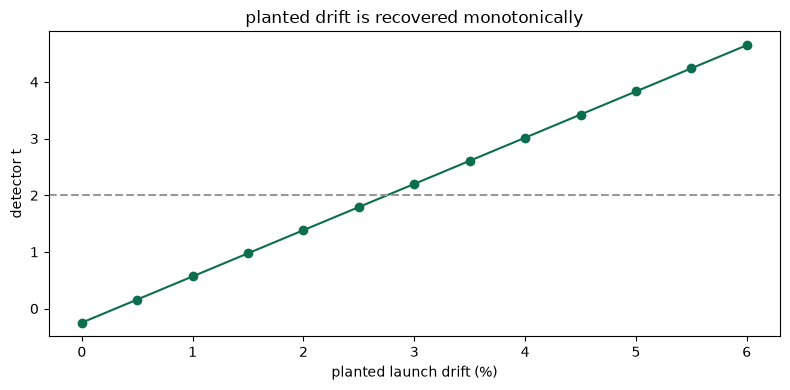

In [7]:
null_ts = np.array([st.synthetic_detect(drift=0.0, seed=846+s, k=20)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for d in (0.02, 0.04):
    r = st.synthetic_detect(drift=d, seed=846, k=20)
    print(f'planted +{d*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
drifts = np.linspace(0, 0.06, 13)
ts = [st.synthetic_detect(drift=d, seed=846, k=20)['t'] for d in drifts]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(drifts*100, ts, 'o-', color='#0b6e4f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted launch drift (%)'); ax.set_ylabel('detector t')
ax.set_title('planted drift is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: None.** Neither half of the folklore survives — the run-up is a faint, insignificant *dip* (2-week −1.58%, *t* = −1.26, HAC *t* = −1.63, the wrong sign for 'buy the hype', placebo right-tail p = 0.94) and the 20-day post-launch drift is a clean zero (−0.17%, *t* = −0.10, hit 16/33, placebo p = 0.60), gone under per-publisher (signs scatter, UBSFY −5.6% vs NTDOY +2.8%) and sub-era (early +1.16% vs late −1.42%) splits. The synthetic control shows a real drift *would* have been caught. **Tradability: Mirage.** No edge gross or net, a losing long into the launch, and no momentum to ride out of it.